This notebook analyzes revenue performance and key business KPIs using the cleaned Olist e-commerce dataset. The objective is to identify revenue trends, customer purchasing behaviour, and key performance drivers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
pd.set_option('display.max_columns', None)

df= pd.read_csv('master_cleaned_dataset.csv')

In [3]:
df['order_purchase_timestamp']= pd.to_datetime(df['order_purchase_timestamp'])

In [4]:
total_revenue= df[['order_id', 'total_order_value']].drop_duplicates()['total_order_value'].sum()

In [6]:
total_orders= df['order_id'].nunique()

In [7]:
aov= total_revenue / total_orders

In [23]:
kpi_summary= pd.DataFrame({
    'Metric':['Total Revenue', 'Total Orders', 'Average Order Value'],
    'Value':[
        f'${total_revenue:,.2f}',
        f'{total_orders:,}',
        f'${aov:,.2f}'
    ]
})

print(kpi_summary)

                Metric           Value
0        Total Revenue  $15,906,937.73
1         Total Orders          95,137
2  Average Order Value         $167.20


The platform generated approximately __$15,906,937.73__ in total revenue across __95,137__orders, resulting in an average order value(AOV) of __$167.20__.

In [8]:
monthly_revenue=(
    df[['order_id','order_purchase_timestamp', 'total_order_value']].drop_duplicates()
)
monthly_revenue['order_month']= monthly_revenue['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue=(
    monthly_revenue.groupby('order_month')['total_order_value'].sum().reset_index()
)
monthly_revenue['order_month']= monthly_revenue['order_month'].astype(str)

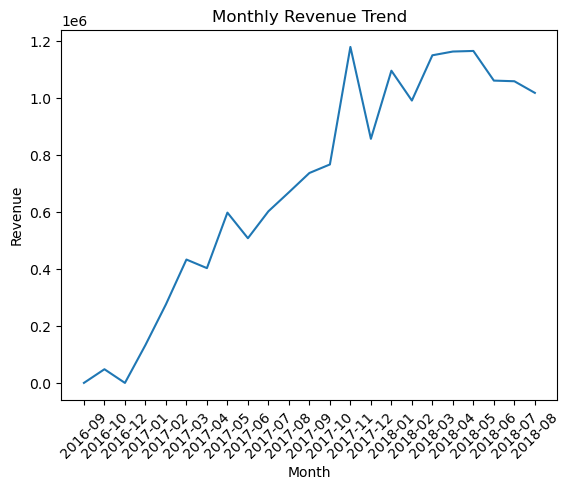

In [9]:
plt.figure()
plt.plot(monthly_revenue['order_month'], monthly_revenue['total_order_value'])
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

Revenue demonstrates clear temporal fluctuations across several months, indicating potential seasonality effects and promotional cycles. Identifying peak and low-performing months provides opportunities for targeted marketing and inventory planning strategies.

In [10]:
monthly_revenue['MoM_growth_%']= monthly_revenue['total_order_value'].pct_change() * 100

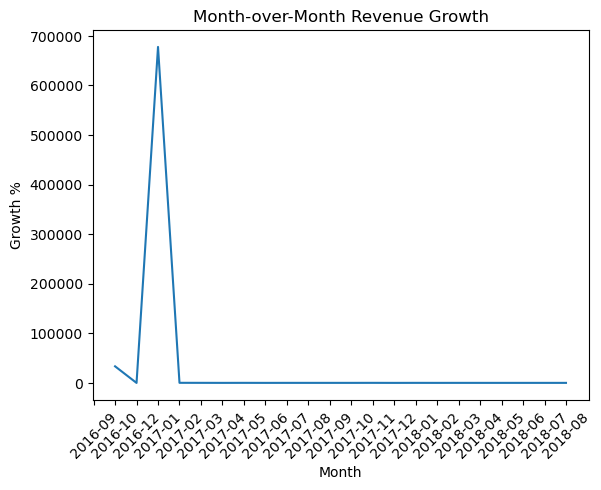

In [12]:
plt.figure()
plt.plot(monthly_revenue['order_month'], monthly_revenue['MoM_growth_%'])
plt.xticks(rotation=45)
plt.title('Month-over-Month Revenue Growth')
plt.xlabel('Month')
plt.ylabel('Growth %')
plt.show()

Month-over-month growth analysis highlights periods of accelerated expansion as well as revenue contractions. Sustained positive growth indicates business momentum, which volatility may signal promotional dependency or external market influences.

In [13]:
category_revenue=(
    df.groupby('product_category_name')['total_item_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

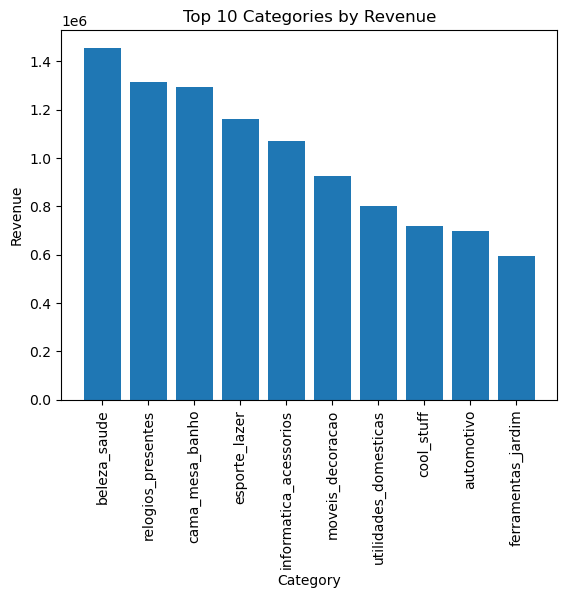

In [14]:
plt.figure()
plt.bar(category_revenue['product_category_name'],
        category_revenue['total_item_value'])
plt.xticks(rotation=90)
plt.title('Top 10 Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()

Revenue concentration within the top product categories indicates core drivers of business performance. Strategic focus on high-performing categories-through inventory optmization and targeted marketing-can maximize revenue impact.

In [16]:
payment_revenue=(
    df.groupby('payment_type')['total_item_value']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

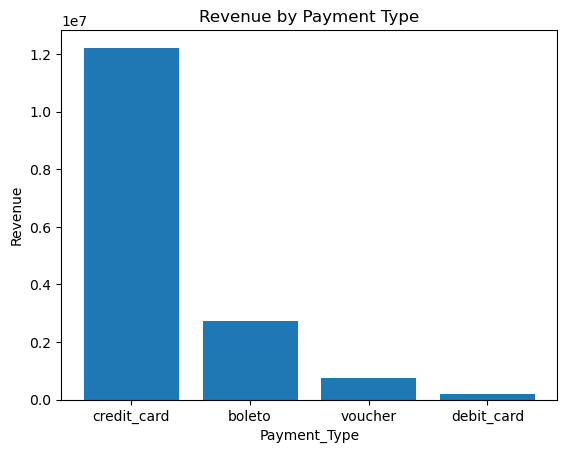

In [17]:
plt.figure()
plt.bar(payment_revenue['payment_type'],
        payment_revenue['total_item_value'])
plt.title('Revenue by Payment Type')
plt.xlabel('Payment_Type')
plt.ylabel('Revenue')
plt.show()

Payment method distribution reveals customer transcation preferences, with certain methods contributing disproportionately to revenue. Understanding preferred payment channels can support checkout optimization and payment provider negotiations.

In [19]:
state_revenue=(
    df.groupby('customer_state')['total_item_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

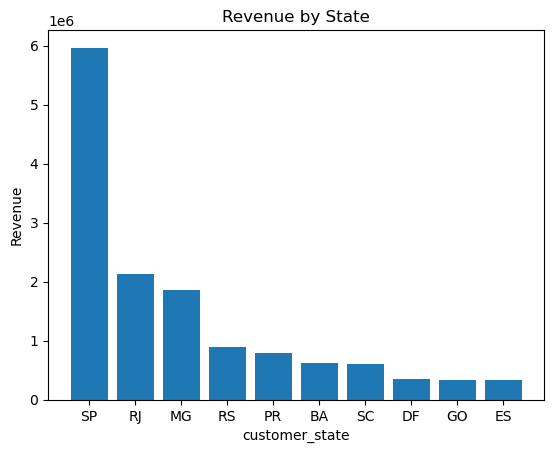

In [20]:
plt.figure()
plt.bar(state_revenue['customer_state'],
        state_revenue['total_item_value'])
plt.title('Revenue by State')
plt.xlabel('customer_state')
plt.ylabel('Revenue')
plt.show()

Geographic revenue distribution highlights regional performance disparities. High-revenue states represent strong market penetration, while underperforming regions may indicate expansion opportunities or logistical constraints.

In [25]:
customer_orders= (
    df[['customer_unique_id', 'order_id']]
    .drop_duplicates()
    .groupby('customer_unique_id')
    .count()
    .reset_index()
)
customer_orders.rename(columns={'order_id':'order_count'}, inplace=True)
customer_orders.head()

,customer_unique_id,order_count
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [26]:
repeat_customers= customer_orders[customer_orders['order_count']>1]

num_repeat_customers= len(repeat_customers)
total_customers= len(customer_orders)

repeat_customer_rate= (num_repeat_customers/ total_customers) * 100

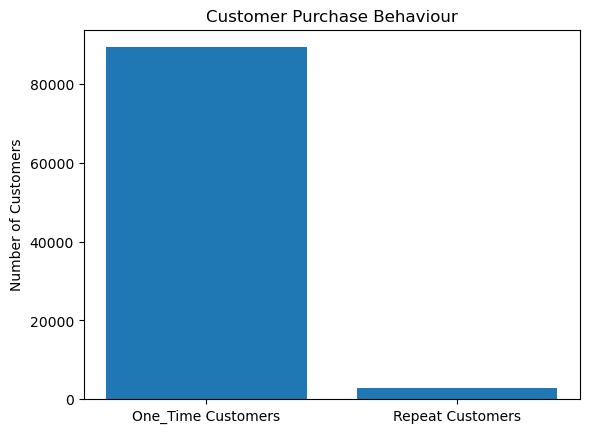

In [28]:
plt.figure()
plt.bar(['One_Time Customers', 'Repeat Customers'],
        [total_customers-num_repeat_customers, num_repeat_customers])
plt.title('Customer Purchase Behaviour')
plt.ylabel('Number of Customers')
plt.show()

The repeat customer rate measure loyalty and customer retention. The relatively low repeat purchase rate suggests significant opportunity to implement retention strategies such as loyalty programs, personalized marketing, or targeted follow-up campaigns.